# Data Analyst Assessment – Solar PV and Battery Analysis

## Purpose

This notebook analyses hourly solar electricity generation and household electricity usage for 2020 to assess the potential financial and operational benefits of installing a 12.5 kWh battery.

The analysis covers:

- Data completeness, quality checks and significant outlier investigation
- Electricity purchased from the provider without a battery
- Excess solar electricity available for battery charging
- Hourly battery charge level
- Electricity purchased from the provider with a battery
- Estimated annual electricity-cost saving
- Monthly analysis of solar generation, electricity usage and provider purchases
- 20-year financial projections under two electricity-price scenarios
- Net Present Value (NPV) and Internal Rate of Return (IRR)

The calculations and assumptions in this notebook are based on the requirements provided in the assessment.

## Key Assessment Assumptions

The following parameters are specified in the assessment:

- Battery installation cost: **$7,000**
- Battery installation date: **1 January 2022**
- Battery expected life: **20 years**
- Maximum battery capacity: **12.5 kWh**
- Minimum battery charge: **0 kWh**
- Electricity price from 1 January 2022: **$0.17/kWh**
- Discount rate for NPV: **6% per annum**
- Scenario 1: electricity prices increase by **4% per annum**
- Scenario 2: electricity-price inflation starts at **4% per annum** and increases by **0.25 percentage points each year**
- Excess solar cannot be stored once the battery reaches its maximum capacity.
- Household electricity usage is met first by current solar generation, then by stored battery energy, and finally by electricity purchased from the provider.
- 29 February 2020 is not included in the supplied data and is therefore not imputed.
- No battery efficiency or charge/discharge-rate adjustment has been applied because no such parameter is specified in the assessment.

In [1]:
import pandas as pd


# Part (i) – Data Completeness, Quality Checks and Outlier Investigation

This section checks the completeness and quality of the supplied 2020 hourly data, investigates significant outliers, makes any necessary corrections, and compares average solar generation and electricity usage by hour of day.

In [3]:
excel_file = "Data for candidate 2026.xlsx"

In [5]:
excel_data = pd.ExcelFile(excel_file)

In [7]:
excel_data.sheet_names

['Raw Data', 'Scoring']

In [9]:
df = pd.read_excel(excel_file, sheet_name="Raw Data")

In [11]:
df.head()

,Hour 0 represents the hour from midnight to 01:00 and hour 23 represents the hour from 23:00 to midnight.,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,DATA,DATA
1,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
2,0,2020-01-01 00:00:00,0,1.509849
3,1,2020-01-01 01:00:00,0,1.411859
4,2,2020-01-01 02:00:00,0,1.023898


In [13]:
df = pd.read_excel(excel_file, sheet_name="Raw Data", header=1)

In [15]:
df.head()

,Unnamed: 0,Unnamed: 1,DATA,DATA.1
0,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
1,0,2020-01-01 00:00:00,0,1.509849
2,1,2020-01-01 01:00:00,0,1.411859
3,2,2020-01-01 02:00:00,0,1.023898
4,3,2020-01-01 03:00:00,0,0.642


In [17]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'DATA', 'DATA.1'], dtype='object')

In [19]:
df.iloc[0]

Unnamed: 0                                  Hour
Unnamed: 1                       Date/hour start
DATA          Solar electricity generation (kWh)
DATA.1                   Electricity usage (kWh)
Name: 0, dtype: object

In [21]:
df.columns = df.iloc[0]

In [23]:
df.columns

Index(['Hour', 'Date/hour start', 'Solar electricity generation (kWh)',
       'Electricity usage (kWh)'],
      dtype='object', name=0)

In [25]:
df = df.iloc[1:].reset_index(drop=True)

In [27]:
df.shape

(8760, 4)

In [29]:
df.head()

,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
0,0,2020-01-01 00:00:00,0,1.509849
1,1,2020-01-01 01:00:00,0,1.411859
2,2,2020-01-01 02:00:00,0,1.023898
3,3,2020-01-01 03:00:00,0,0.642
4,4,2020-01-01 04:00:00,0,0.96


In [ ]:
df["Date/hour start"] = pd.to_datetime(df["Date/hour start"])

In [33]:
df["Date/hour start"].diff().value_counts()

Date/hour start
0 days 01:00:00    8758
1 days 01:00:00       1
Name: count, dtype: int64

In [35]:
df.loc[df["Date/hour start"].diff() > pd.Timedelta(hours=1),
       ["Date/hour start", "Hour"]]

,Date/hour start,Hour
1416,2020-03-01,0


In [37]:
df["Date/hour start"].duplicated().sum()

0

In [39]:
df["Solar electricity generation (kWh)"] < 0

0       False
1       False
2       False
3       False
4       False
        ...  
8755    False
8756    False
8757    False
8758    False
8759    False
Name: Solar electricity generation (kWh), Length: 8760, dtype: bool

In [41]:
(df["Solar electricity generation (kWh)"] < 0).sum()

0

In [43]:
(df["Electricity usage (kWh)"] < 0).sum()

5

In [45]:
df.loc[
    df["Electricity usage (kWh)"] < 0,
    ["Hour", "Date/hour start", "Solar electricity generation (kWh)", "Electricity usage (kWh)"]
]

,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
17,17,2020-01-01 17:00:00,0.006,-12.624
933,21,2020-02-08 21:00:00,0.006,-2.133
935,23,2020-02-08 23:00:00,0,-0.2175
3593,17,2020-05-30 17:00:00,1.185,-2.514
6464,8,2020-09-27 08:00:00,0.717,-1.977


In [47]:
negative_rows = df[df["Electricity usage (kWh)"] < 0].index

for i in negative_rows:
    print("\n--- Negative observation ---")
    print(df.loc[max(0, i-2):i+2,
                 ["Hour",
                  "Date/hour start",
                  "Solar electricity generation (kWh)",
                  "Electricity usage (kWh)"]])


--- Negative observation ---
0  Hour     Date/hour start Solar electricity generation (kWh)  \
15   15 2020-01-01 15:00:00                              0.159   
16   16 2020-01-01 16:00:00                              0.081   
17   17 2020-01-01 17:00:00                              0.006   
18   18 2020-01-01 18:00:00                                  0   
19   19 2020-01-01 19:00:00                              0.021   

0  Electricity usage (kWh)  
15                   1.437  
16                   3.105  
17                 -12.624  
18                  8.9298  
19                  2.2176  

--- Negative observation ---
0   Hour     Date/hour start Solar electricity generation (kWh)  \
931   19 2020-02-08 19:00:00                              0.021   
932   20 2020-02-08 20:00:00                              0.006   
933   21 2020-02-08 21:00:00                              0.006   
934   22 2020-02-08 22:00:00                              0.009   
935   23 2020-02-08 23:00:00      

In [49]:
df[[
    "Solar electricity generation (kWh)",
    "Electricity usage (kWh)"
]].describe()

,Solar electricity generation (kWh),Electricity usage (kWh)
count,8760,8760
unique,1774,2761
top,0,0
freq,2311,136


In [51]:
df.dtypes

0
Hour                                          object
Date/hour start                       datetime64[ns]
Solar electricity generation (kWh)            object
Electricity usage (kWh)                       object
dtype: object

In [53]:
df[["Hour",
    "Solar electricity generation (kWh)",
    "Electricity usage (kWh)"
]].head(10)

,Hour,Solar electricity generation (kWh),Electricity usage (kWh)
0,0,0,1.509849
1,1,0,1.411859
2,2,0,1.023898
3,3,0,0.642
4,4,0,0.96
5,5,0.012,0.897
6,6,0.006,0.648
7,7,0.009,0.774
8,8,0.012,1.299
9,9,0.846,0.606


In [55]:
df[[
    "Hour",
    "Solar electricity generation (kWh)",
    "Electricity usage (kWh)"
]].map(type).nunique()

0
Hour                                  1
Solar electricity generation (kWh)    2
Electricity usage (kWh)               2
dtype: int64

In [59]:
df["Solar electricity generation (kWh)"].map(type).value_counts()

Solar electricity generation (kWh)
<class 'float'>    6447
<class 'int'>      2313
Name: count, dtype: int64

In [61]:
df["Electricity usage (kWh)"].map(type).value_counts()

Electricity usage (kWh)
<class 'float'>    8620
<class 'int'>       140
Name: count, dtype: int64

In [63]:
df["Solar electricity generation (kWh)"] = pd.to_numeric(df["Solar electricity generation (kWh)"])

In [65]:
df["Electricity usage (kWh)"] = pd.to_numeric(df["Electricity usage (kWh)"])

In [67]:
df.dtypes

0
Hour                                          object
Date/hour start                       datetime64[ns]
Solar electricity generation (kWh)           float64
Electricity usage (kWh)                      float64
dtype: object

In [69]:
Q1 = df["Electricity usage (kWh)"].quantile(0.25)
Q3 = df["Electricity usage (kWh)"].quantile(0.75)

IQR = Q3 - Q1

Q1, Q3, IQR

(0.30000000000000004, 1.6860000000000002, 1.3860000000000001)

In [71]:
outliers = df[
    (df["Electricity usage (kWh)"] < -1.779) |
    (df["Electricity usage (kWh)"] > 3.765)
]

len(outliers)

989

In [73]:
df["Electricity usage (kWh)"].nlargest(10)

276     46000.0000
8635       61.1028
1579       59.6046
8011       58.7400
8348       58.2450
8300       57.5652
8276       57.5058
8204       57.4530
2202       57.4398
1603       57.0702
Name: Electricity usage (kWh), dtype: float64

In [75]:
df.loc[276]

0
Hour                                                   12
Date/hour start                       2020-01-12 12:00:00
Solar electricity generation (kWh)                  5.214
Electricity usage (kWh)                           46000.0
Name: 276, dtype: object

In [77]:
df.loc[274:278]

,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
274,10,2020-01-12 10:00:00,0.951,0.444
275,11,2020-01-12 11:00:00,3.315,0.387
276,12,2020-01-12 12:00:00,5.214,46000.000
277,13,2020-01-12 13:00:00,4.848,0.573
278,14,2020-01-12 14:00:00,0.777,0.459


In [79]:
df_clean = df.copy()

In [81]:
df_clean.loc[
    (df_clean["Electricity usage (kWh)"] < 0) |
    (df_clean["Electricity usage (kWh)"] == 46000),
    "Electricity usage (kWh)"
] = pd.NA

In [83]:
df_clean["Electricity usage (kWh)"] = df_clean["Electricity usage (kWh)"].interpolate()

In [85]:
df_clean["Electricity usage (kWh)"].isna().sum()

0

In [87]:
df_clean["Hour"] = df_clean["Date/hour start"].dt.hour

In [89]:
hourly_averages = df_clean.groupby("Hour")[
    ["Solar electricity generation (kWh)", "Electricity usage (kWh)"]
].mean()

In [91]:
import matplotlib.pyplot as plt

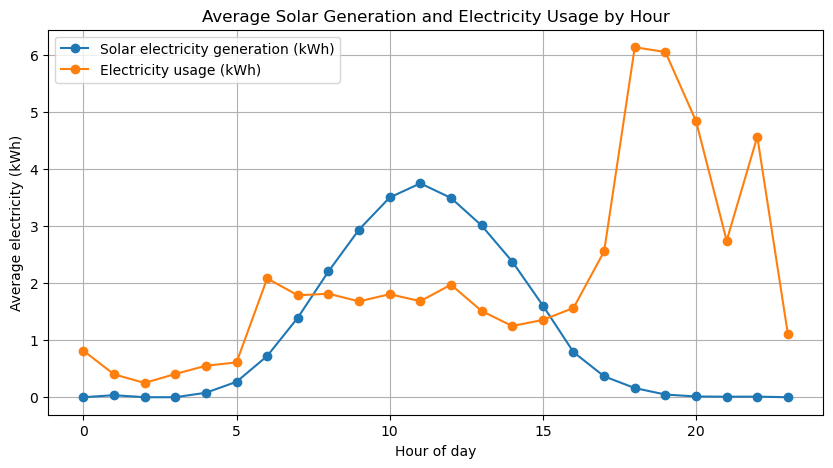

In [93]:
hourly_averages.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Average electricity (kWh)")
plt.title("Average Solar Generation and Electricity Usage by Hour")
plt.legend()
plt.grid()
plt.show()

# Part (ii) – Electricity Purchased Without Battery

Calculate the electricity that would be purchased from the provider for each hour without battery storage.

In [95]:
df_clean["Electricity purchased (no battery)"] = (
    df_clean["Electricity usage (kWh)"] -
    df_clean["Solar electricity generation (kWh)"]
).clip(lower=0)

In [97]:
df_clean["Electricity purchased (no battery)"].describe()

count    8760.000000
mean        1.785315
std         4.532165
min         0.000000
25%         0.000000
50%         0.345483
75%         1.488000
max        61.096800
Name: Electricity purchased (no battery), dtype: float64

In [99]:
df_clean["Electricity purchased (no battery)"].sum()

15639.3596383

# Part (iii) – Excess Solar Electricity

Calculate the excess solar electricity generated over electricity used for each hour.

In [101]:
df_clean["Excess solar (kWh)"] = (
    df_clean["Solar electricity generation (kWh)"] -
    df_clean["Electricity usage (kWh)"]
).clip(lower=0)

In [103]:
df_clean["Excess solar (kWh)"].describe()

count    8760.000000
mean        0.836396
std         1.886998
min         0.000000
25%         0.000000
50%         0.000000
75%         0.435750
max        12.734032
Name: Excess solar (kWh), dtype: float64

# Part (iv) – Battery Charge Level

Model the battery charge level for each hour, starting at zero and subject to the 12.5 kWh maximum capacity.

In [105]:
df_clean["Battery charge level (kWh)"] = 0.0

In [107]:
battery_charge = 0.0

for i in range(len(df_clean)):
    battery_charge = battery_charge + df_clean.loc[i, "Excess solar (kWh)"] - df_clean.loc[i, "Electricity purchased (no battery)"]
    battery_charge = max(0, min(battery_charge, 12.5))
    df_clean.loc[i, "Battery charge level (kWh)"] = battery_charge

In [109]:
df_clean["Battery charge level (kWh)"].describe()

count    8760.000000
mean        3.211185
std         4.689398
min         0.000000
25%         0.000000
50%         0.000000
75%         5.964750
max        12.500000
Name: Battery charge level (kWh), dtype: float64

# Part (v) – Electricity Purchased With Battery

Calculate the electricity that would be purchased from the provider for each hour after allowing for battery discharge.

In [111]:
df_clean["Battery discharge (kWh)"] = 0.0

In [113]:
df_clean["Previous battery charge (kWh)"] = (
    df_clean["Battery charge level (kWh)"].shift(1).fillna(0)
)

In [115]:
df_clean["Battery discharge (kWh)"] = (
    df_clean[
        ["Previous battery charge (kWh)", "Electricity purchased (no battery)"]
    ].min(axis=1)
)

In [117]:
df_clean["Electricity purchased (with battery)"] = (
    df_clean["Electricity purchased (no battery)"] -
    df_clean["Battery discharge (kWh)"]
)

In [119]:
df_clean["Electricity purchased (with battery)"].describe()

count    8760.000000
mean        1.385514
std         4.174461
min         0.000000
25%         0.000000
50%         0.162000
75%         0.981902
max        61.096800
Name: Electricity purchased (with battery), dtype: float64

In [121]:
df_clean["Electricity purchased (with battery)"].sum()

12137.0998325

In [123]:
df_clean["Electricity purchased (no battery)"].sum() - df_clean["Electricity purchased (with battery)"].sum()

3502.2598058000003

# Part (vi) – 2020 Saving

Calculate the implied electricity-cost saving from using the battery compared with solar panels alone, using the 1 January 2022 electricity price.

In [125]:
saving_2020 = (
    df_clean["Electricity purchased (no battery)"].sum()
    - df_clean["Electricity purchased (with battery)"].sum()
) * 0.17

saving_2020

595.3841669860001

# Part (vii) – Monthly Analysis

Aggregate the results by month to compare solar generation, electricity usage, and provider purchases with and without the battery.

In [127]:
df_clean["Month"] = df_clean["Date/hour start"].dt.to_period("M")

In [129]:
monthly_data = df_clean.groupby("Month")[
    [
        "Solar electricity generation (kWh)",
        "Electricity usage (kWh)",
        "Electricity purchased (no battery)",
        "Electricity purchased (with battery)"
    ]
].sum()

In [131]:
monthly_data

,Solar electricity generation (kWh),Electricity usage (kWh),Electricity purchased (no battery),Electricity purchased (with battery)
Month,,,,
2020-01,266.259,1724.301581,1605.612581,1469.186581
2020-02,449.634,1564.115454,1396.988454,1195.097454
2020-03,602.451,1797.859450,1619.011450,1384.846450
2020-04,915.132,1726.356487,1460.504519,1144.120799
2020-05,1641.360,948.061109,717.892109,339.930493
2020-06,1408.287,1158.995538,844.784538,447.593233
2020-07,1371.465,1196.957121,907.445121,470.627352
2020-08,1158.639,1491.525351,1217.886351,792.621935
2020-09,835.680,1626.769665,1402.195665,1044.199860


In [133]:
monthly_data.index = monthly_data.index.strftime("%b")

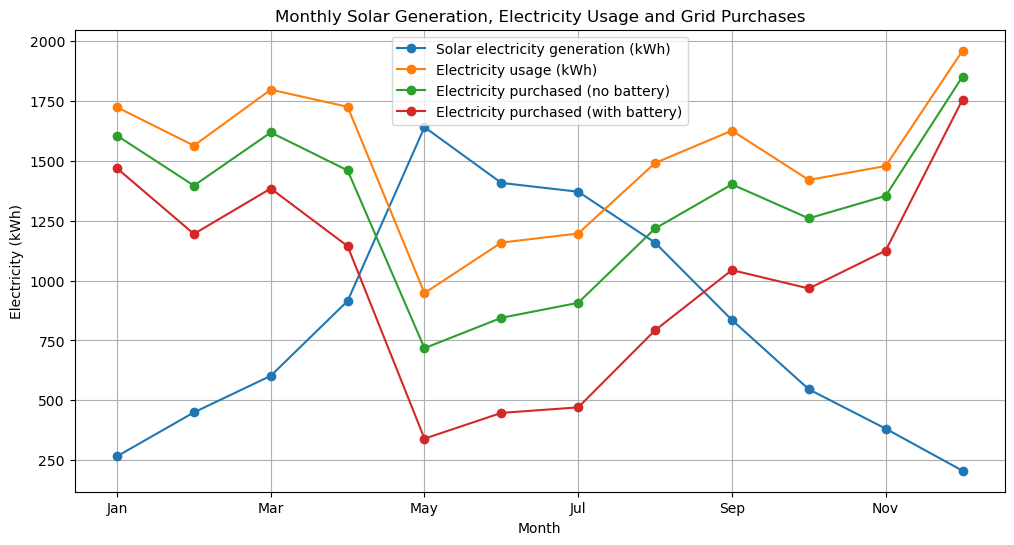

In [135]:
monthly_data.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Electricity (kWh)")
plt.title("Monthly Solar Generation, Electricity Usage and Grid Purchases")
plt.legend()
plt.grid()
plt.show()

# Part (viii) – 20-Year Savings and NPV

Project annual battery savings over 20 years from 1 January 2022 under the two electricity-price scenarios and calculate the NPV for each scenario.

In [137]:
avoided_kwh = 3502.2598058
starting_price = 0.17
price_inflation_scenario1 = 0.04
battery_cost = 7000
discount_rate = 0.06

In [139]:
years = list(range(2022, 2042))

scenario1_prices = [
    starting_price * (1 + price_inflation_scenario1) ** (year - 2022)
    for year in years
]

In [141]:
scenario1_savings = [
    avoided_kwh * price
    for price in scenario1_prices
]

In [143]:
list(zip(years, scenario1_prices, scenario1_savings))

[(2022, 0.17, 595.384166986),
 (2023, 0.1768, 619.1995336654401),
 (2024, 0.18387200000000004, 643.9675150120577),
 (2025, 0.19122688000000002, 669.7262156125399),
 (2026, 0.19887595520000004, 696.5152642370416),
 (2027, 0.20683099340800004, 724.3758748065233),
 (2028, 0.2151042331443201, 753.3509097987844),
 (2029, 0.22370840247009285, 783.4849461907356),
 (2030, 0.23265673856889657, 814.8243440383651),
 (2031, 0.24196300811165247, 847.4173177998998),
 (2032, 0.25164152843611853, 881.3140105118956),
 (2033, 0.2617071895735633, 916.5665709323716),
 (2034, 0.27217547715650586, 953.2292337696665),
 (2035, 0.28306249624276614, 991.3584031204533),
 (2036, 0.29438499609247676, 1031.0127392452714),
 (2037, 0.30616039593617583, 1072.2532488150823),
 (2038, 0.3184068117736229, 1115.1433787676856),
 (2039, 0.3311430842445678, 1159.749113918393),
 (2040, 0.3443888076143506, 1206.139078475129),
 (2041, 0.3581643599189246, 1254.3846416141341)]

In [145]:
scenario1_npv = -battery_cost + sum(
    saving / (1 + discount_rate) ** (year - 2021)
    for year, saving in zip(years, scenario1_savings)
)

scenario1_npv

2430.809198693116

In [147]:
scenario2_inflation = [
    0 if year == 2022 else 0.04 + 0.0025 * (year - 2023)
    for year in years
]

In [149]:
list(zip(years, scenario2_inflation))

[(2022, 0),
 (2023, 0.04),
 (2024, 0.0425),
 (2025, 0.045),
 (2026, 0.0475),
 (2027, 0.05),
 (2028, 0.052500000000000005),
 (2029, 0.055),
 (2030, 0.0575),
 (2031, 0.06),
 (2032, 0.0625),
 (2033, 0.065),
 (2034, 0.0675),
 (2035, 0.07),
 (2036, 0.07250000000000001),
 (2037, 0.07500000000000001),
 (2038, 0.0775),
 (2039, 0.08),
 (2040, 0.0825),
 (2041, 0.08499999999999999)]

In [151]:
scenario2_prices = [starting_price]

for inflation in scenario2_inflation[1:]:
    scenario2_prices.append(
        scenario2_prices[-1] * (1 + inflation)
    )

In [153]:
list(zip(years, scenario2_prices))

[(2022, 0.17),
 (2023, 0.1768),
 (2024, 0.184314),
 (2025, 0.19260813),
 (2026, 0.201757016175),
 (2027, 0.21184486698375002),
 (2028, 0.2229667225003969),
 (2029, 0.2352298922379187),
 (2030, 0.24875561104159907),
 (2031, 0.263680947704095),
 (2032, 0.2801610069356009),
 (2033, 0.298371472386415),
 (2034, 0.318511546772498),
 (2035, 0.3408073550465729),
 (2036, 0.3655158882874494),
 (2037, 0.3929295799090081),
 (2038, 0.4233816223519562),
 (2039, 0.4572521521401127),
 (2040, 0.49497545469167203),
 (2041, 0.5370483683404641)]

In [155]:
scenario2_savings = [
    avoided_kwh * price
    for price in scenario2_prices
]

In [157]:
list(zip(years, scenario2_savings))

[(2022, 595.384166986),
 (2023, 619.1995336654401),
 (2024, 645.5155138462212),
 (2025, 674.563711969301),
 (2026, 706.605488287843),
 (2027, 741.9357627022351),
 (2028, 780.8873902441024),
 (2029, 823.8361967075281),
 (2030, 871.206778018211),
 (2031, 923.4791846993037),
 (2032, 981.1966337430101),
 (2033, 1044.9744149363057),
 (2034, 1115.5101879445065),
 (2035, 1193.595901100622),
 (2036, 1280.131603930417),
 (2037, 1376.1414742251984),
 (2038, 1482.792438477651),
 (2039, 1601.4158335558632),
 (2040, 1733.5326398242219),
 (2041, 1880.8829142092807)]

In [159]:
scenario2_npv = -battery_cost + sum(
    saving / (1 + discount_rate) ** (year - 2021)
    for year, saving in zip(years, scenario2_savings)
)

scenario2_npv

3741.7959064925326

# Part (ix) – Internal Rate of Return

Calculate the IRR for each electricity-price scenario based on the initial battery cost and projected annual savings.

In [161]:
scenario1_cash_flows = [-battery_cost] + scenario1_savings

In [165]:
def calculate_npv(rate, cash_flows):
    return sum(
        cash_flow / (1 + rate) ** period
        for period, cash_flow in enumerate(cash_flows)
    )

In [167]:
calculate_npv(0.06, scenario1_cash_flows)

2430.809198693116

In [169]:
low = 0.0
high = 1.0

for _ in range(100):
    mid = (low + high) / 2
    npv = calculate_npv(mid, scenario1_cash_flows)

    if npv > 0:
        low = mid
    else:
        high = mid

scenario1_irr = (low + high) / 2

scenario1_irr

0.09434455937783859

In [171]:
scenario2_cash_flows = [-battery_cost] + scenario2_savings

In [173]:
low = 0.0
high = 1.0

for _ in range(100):
    mid = (low + high) / 2
    npv = calculate_npv(mid, scenario2_cash_flows)

    if npv > 0:
        low = mid
    else:
        high = mid

scenario2_irr = (low + high) / 2

scenario2_irr

0.10716703808094852

# Final Results and Reasonableness Checks

The final results are summarised below. Additional checks were performed throughout the model to confirm that the calculated electricity purchases and battery charge levels remain within their expected limits and that the financial calculations are consistent with the model assumptions.

In [175]:
financial_results = pd.DataFrame({
    "Scenario": [
        "Scenario 1: 4% annual price increase",
        "Scenario 2: Inflation increases by 0.25 percentage points annually"
    ],
    "NPV ($)": [scenario1_npv, scenario2_npv],
    "IRR (%)": [scenario1_irr * 100, scenario2_irr * 100]
})

financial_results.round({
    "NPV ($)": 2,
    "IRR (%)": 2
})

,Scenario,NPV ($),IRR (%)
0,Scenario 1: 4% annual price increase,2430.81,9.43
1,Scenario 2: Inflation increases by 0.25 percen...,3741.80,10.72


In [177]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total electricity purchased - no battery (kWh)",
        "Total electricity purchased - with battery (kWh)",
        "Electricity avoided through battery (kWh)",
        "2020 saving at $0.17/kWh ($)",
        "Scenario 1 NPV ($)",
        "Scenario 1 IRR (%)",
        "Scenario 2 NPV ($)",
        "Scenario 2 IRR (%)"
    ],
    "Value": [
        df_clean["Electricity purchased (no battery)"].sum(),
        df_clean["Electricity purchased (with battery)"].sum(),
        avoided_kwh,
        saving_2020,
        scenario1_npv,
        scenario1_irr * 100,
        scenario2_npv,
        scenario2_irr * 100
    ]
})

final_summary.round(2)

,Metric,Value
0,Total electricity purchased - no battery (kWh),15639.36
1,Total electricity purchased - with battery (kWh),12137.10
2,Electricity avoided through battery (kWh),3502.26
3,2020 saving at $0.17/kWh ($),595.38
4,Scenario 1 NPV ($),2430.81
5,Scenario 1 IRR (%),9.43
6,Scenario 2 NPV ($),3741.80
7,Scenario 2 IRR (%),10.72
